In [ ]:
import os
import zipfile

# Set the path to your zip file
zip_path = '/content/augment_dataset3.zip'  # Path to your zip file
extract_path = '/content/'  # Destination path for extraction

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [ ]:
!rm -rf {"/content/runs"}

In [ ]:
!pip install ultralytics

Augmented vs Not Augmented

SGD vs Adam vs AdamW

lr = 0.1, 0.01, 0.001

---

Baseline = Not Augmented, SGD, lr=0.1

Test for Optimizers

Test for Learning Rates



In [ ]:
from ultralytics import YOLO
def train_model(name, a=[0.5,0.2,0.015,0.7,0.4,0.5,0.5], batch_size=64, optimizer='AdamW', lr = 0.0013, epochs = 500, imgsz=608, model_path='yolov8n.pt', data='augment_data.yaml'):
  model = YOLO(model_path)
  results = model.train(
      optimizer=optimizer,
      lr0=lr,
      data=data,
      epochs=epochs,
      imgsz=imgsz,
      batch=batch_size,
      device='cuda',
      name=name,
      pretrained=True,
      augment=True,
      mosaic=a[0],
      mixup=a[1],
      hsv_h=a[2],
      hsv_s=a[3],
      hsv_v=a[4],
      flipud=a[5],
      fliplr=a[6],
      seed=42,
      patience=300
  )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
train_model(name='200_Epoch_SGD', a=[1.0,0.1,0.1,1.0,1.0,0.5,0.0], optimizer='SGD', epochs=200)
train_model('500_Epoch_AdamW', lr=0.0013, epochs=500, imgsz=608)
train_model('500_Epoch_AdamW2', lr=0.03, epochs=200, imgsz=640)
train_model('500_Epoch_AdamW3', lr=0.0013, epochs=300, imgsz=640, model_path='runs/detect/500_Epoch_AdamW2/weights/best.pt')
train_model('500_Epoch_AdamW3', lr=0.0001, epochs=100, imgsz=640, model_path='runs/detect/500_Epoch_AdamW2/weights/best.pt')
train_model('500_Epoch_AdamW3', lr=0.03, epochs=500, imgsz=640)
train_model('500_Epoch_AdamW3', lr=0.03, epochs=500, imgsz=640, data='augment_dataset2.yaml', batch_size=128)

In [ ]:
train_model(name='200_Epoch_SGD', a=[1.0,0.1,0.1,1.0,1.0,0.5,0.0], optimizer='SGD', epochs=200, data='augment_dataset3.yaml')

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=augment_dataset3.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.1, hsv_s=1.0, hsv_v=1.0, imgsz=608, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0013, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=200_Epoch_SGD, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=300, perspective=0.0, plots=True, pose=12.

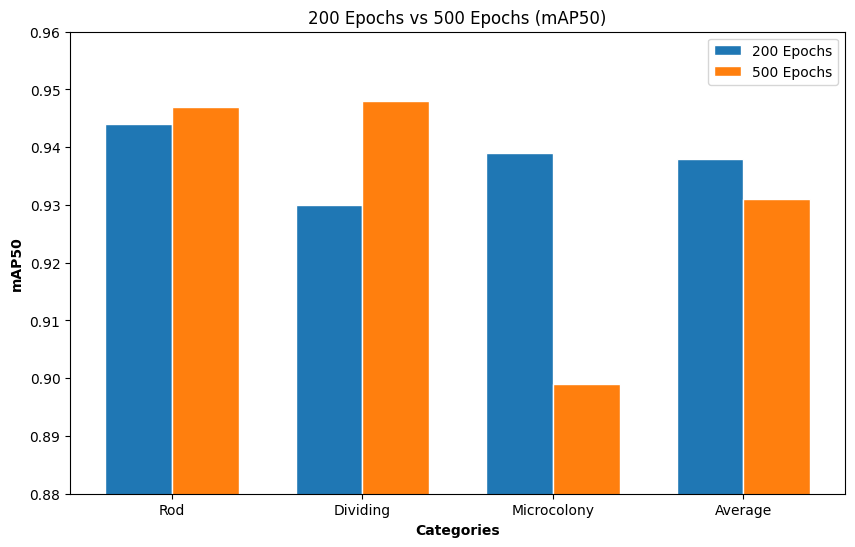

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Rod', 'Dividing', 'Microcolony', 'Average']
values1 = [0.944, 0.93, 0.939, 0.938]
values2 = [0.947, 0.948, 0.899, 0.931]

# Set the bar width
bar_width = 0.35

# Set the positions of the bars on the x-axis
r1 = np.arange(len(categories))
r2 = [x + bar_width for x in r1]

# Create the plot
plt.figure(figsize=(10, 6)) # Optional: Adjust figure size
plt.bar(r1, values1, color='tab:blue', width=bar_width, edgecolor='white', label='200 Epochs')
plt.bar(r2, values2, color='tab:orange', width=bar_width, edgecolor='white', label='500 Epochs')

# Add labels, title, and custom x-axis tick labels
plt.xlabel('Categories', fontweight='bold')
plt.ylabel('mAP50', fontweight='bold')
plt.title('200 Epochs vs 500 Epochs (mAP50)')
plt.xticks([r + bar_width / 2 for r in r1], categories)
plt.ylim(0.88, 0.96)
# Add a legend
plt.legend()

# Display the plot
plt.show()


In [ ]:
metrics = model.val()

NameError: name 'model' is not defined

[]

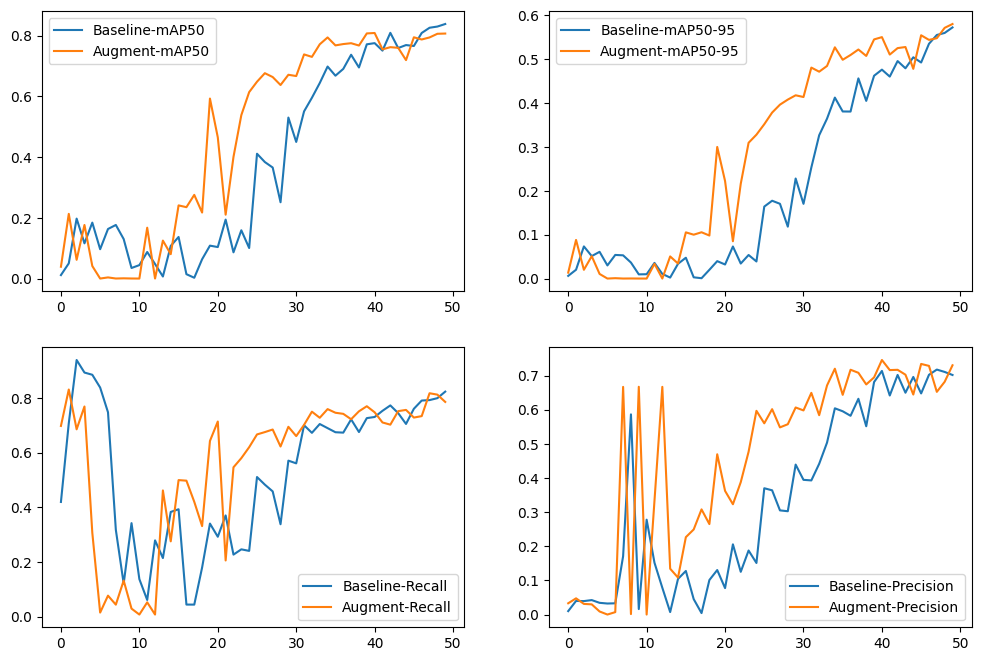

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

baseline_result = 'runs/detect/baseline_model/results.csv'
augment_baseline_result = 'runs/detect/augment_baseline_model/results.csv'
df1 = pd.read_csv(baseline_result)
df2 = pd.read_csv(augment_baseline_result)

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='Baseline-mAP50')
plt.plot(df2['metrics/mAP50(B)'], label='Augment-mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='Baseline-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'], label='Augment-mAP50-95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='Baseline-Recall')
plt.plot(df2['metrics/recall(B)'], label='Augment-Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='Baseline-Precision')
plt.plot(df2['metrics/precision(B)'], label='Augment-Precision')
plt.legend()

plt.plot()



[]

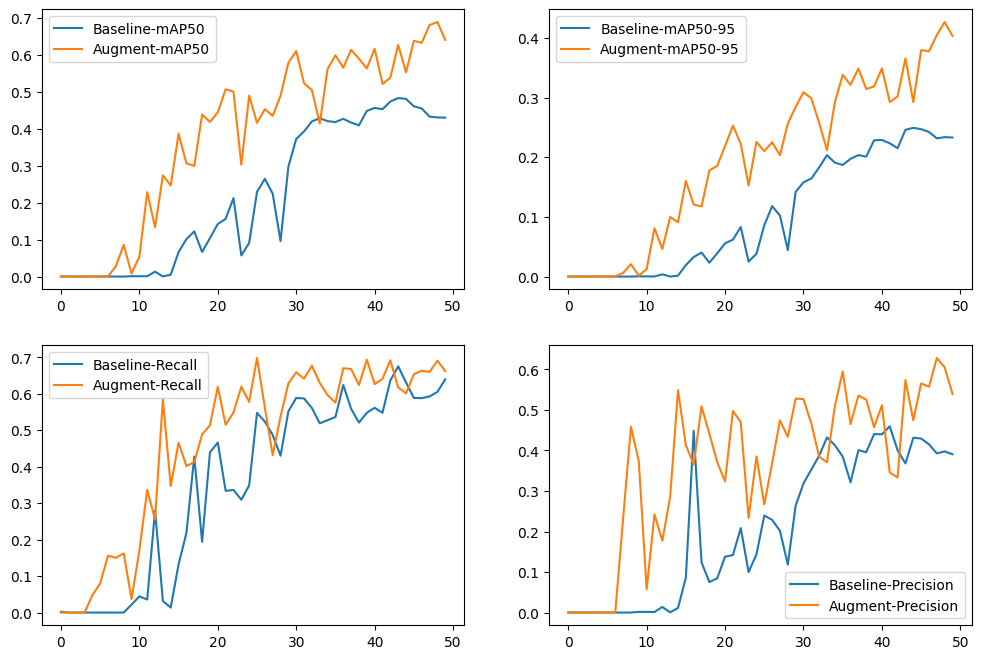

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

adam_result = 'runs/detect/adam_model/results.csv'
augment_adam_result = 'runs/detect/augment_adam_model/results.csv'
df1 = pd.read_csv(adam_result)
df2 = pd.read_csv(augment_adam_result)

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='Baseline-mAP50')
plt.plot(df2['metrics/mAP50(B)'], label='Augment-mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='Baseline-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'], label='Augment-mAP50-95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='Baseline-Recall')
plt.plot(df2['metrics/recall(B)'], label='Augment-Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='Baseline-Precision')
plt.plot(df2['metrics/precision(B)'], label='Augment-Precision')
plt.legend()

plt.plot()



[]

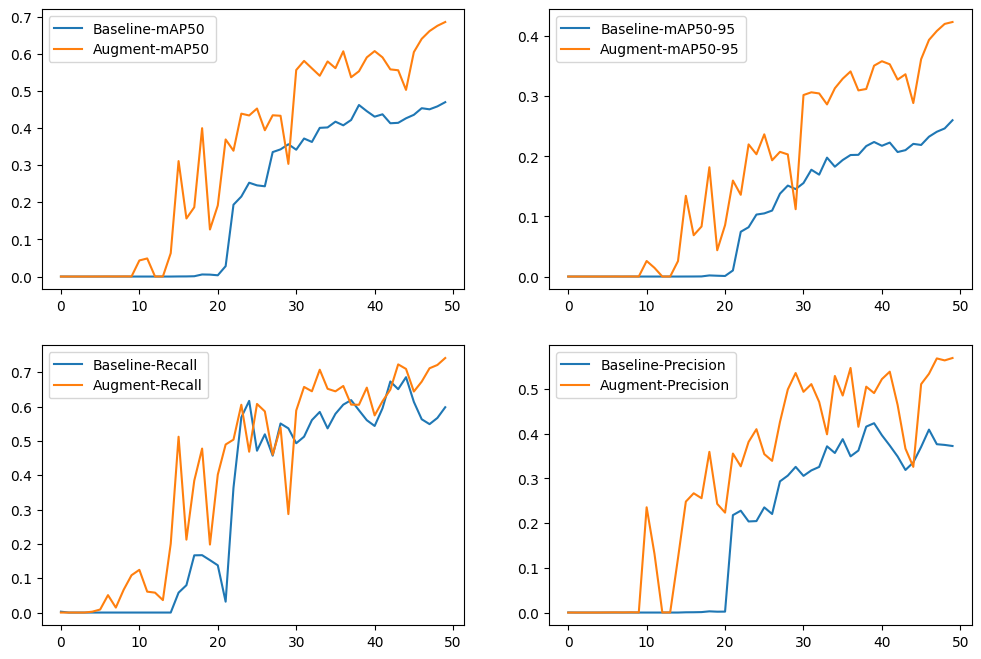

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

adamW_result = 'runs/detect/adamW_model/results.csv'
augment_adamW_result = 'runs/detect/augment_adamW_model/results.csv'
df1 = pd.read_csv(adamW_result)
df2 = pd.read_csv(augment_adamW_result)

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='Baseline-mAP50')
plt.plot(df2['metrics/mAP50(B)'], label='Augment-mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='Baseline-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'], label='Augment-mAP50-95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='Baseline-Recall')
plt.plot(df2['metrics/recall(B)'], label='Augment-Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='Baseline-Precision')
plt.plot(df2['metrics/precision(B)'], label='Augment-Precision')
plt.legend()

plt.plot()



[]

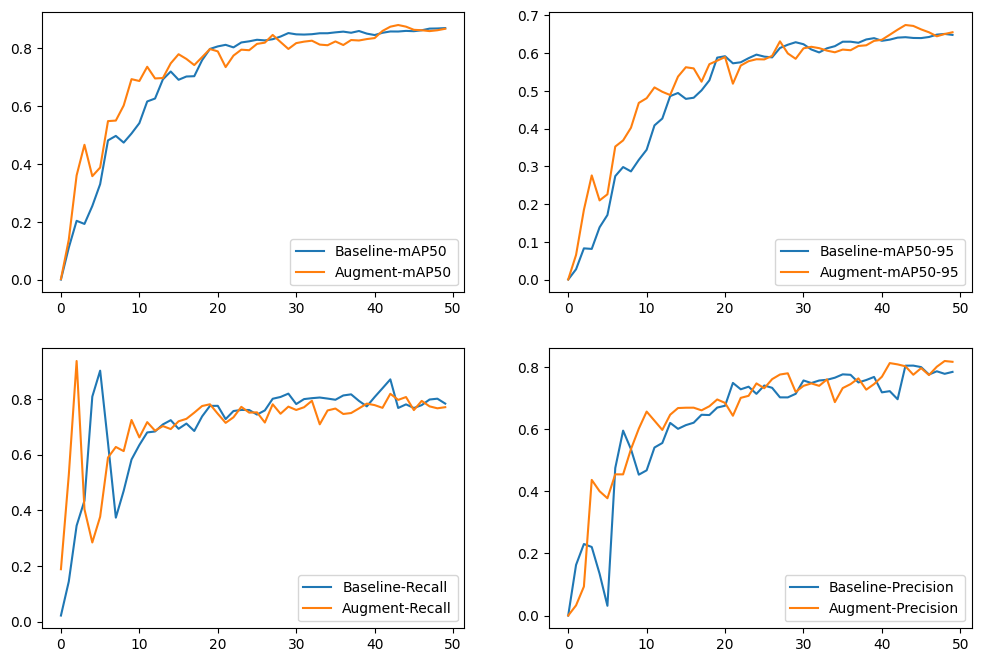

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

slow_adamW_result = 'runs/detect/slow_adamW_model/results.csv'
augment_slow_adamW_result = 'runs/detect/augment_slow_adamW_model/results.csv'
df1 = pd.read_csv(slow_adamW_result)
df2 = pd.read_csv(augment_slow_adamW_result)

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='Baseline-mAP50')
plt.plot(df2['metrics/mAP50(B)'], label='Augment-mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='Baseline-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'], label='Augment-mAP50-95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='Baseline-Recall')
plt.plot(df2['metrics/recall(B)'], label='Augment-Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='Baseline-Precision')
plt.plot(df2['metrics/precision(B)'], label='Augment-Precision')
plt.legend()

plt.plot()



[]

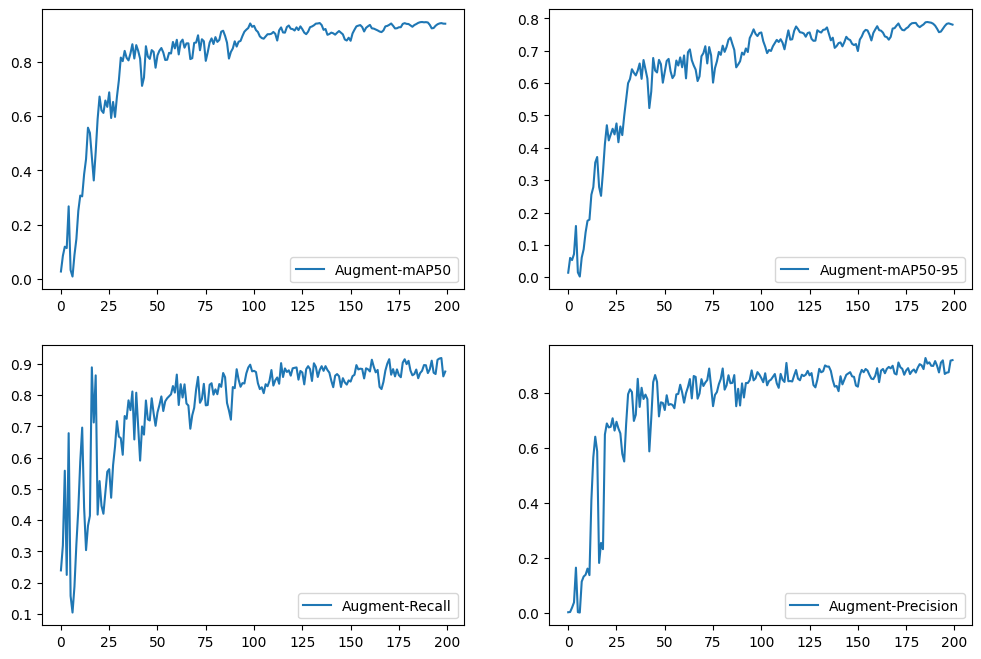

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

augment_slow_adamW_result = 'runs/detect/augment_slow_adamW_model/results.csv'
df2 = pd.read_csv(augment_slow_adamW_result)

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df2['metrics/mAP50(B)'], label='Augment-mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df2['metrics/mAP50-95(B)'], label='Augment-mAP50-95')
plt.legend()

plt.subplot(223)
plt.plot(df2['metrics/recall(B)'], label='Augment-Recall')
plt.legend()

plt.subplot(224)
plt.plot(df2['metrics/precision(B)'], label='Augment-Precision')
plt.legend()

plt.plot()



In [ ]:
import time
time.sleep(600)

KeyboardInterrupt: 

[]

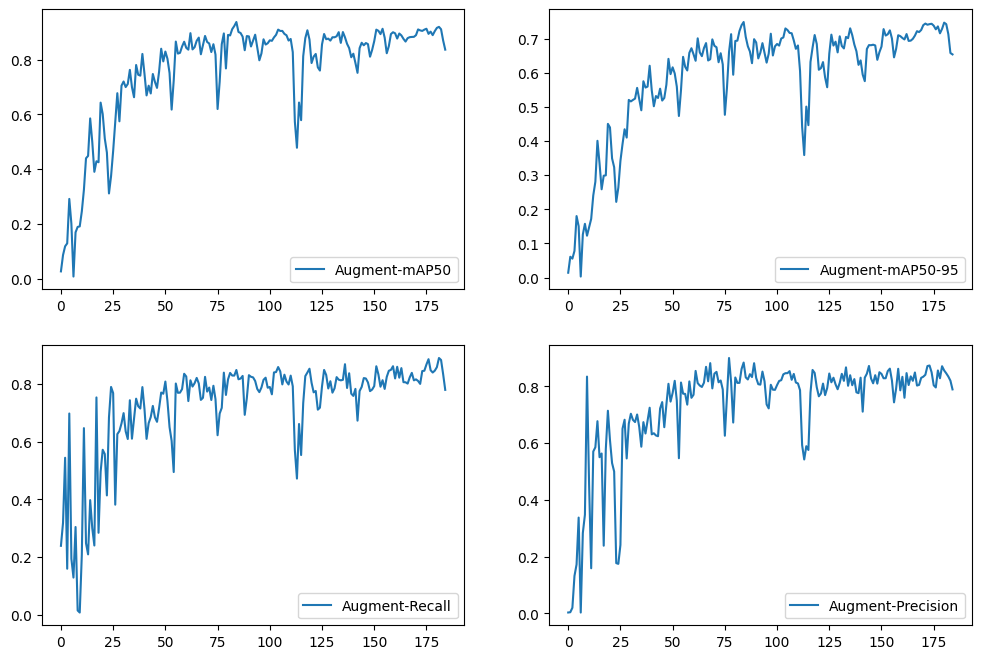

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

augment_slow_adamW_result = 'runs/detect/500_Epoch_AdamW/results.csv'
df2 = pd.read_csv(augment_slow_adamW_result)

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df2['metrics/mAP50(B)'], label='Augment-mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df2['metrics/mAP50-95(B)'], label='Augment-mAP50-95')
plt.legend()

plt.subplot(223)
plt.plot(df2['metrics/recall(B)'], label='Augment-Recall')
plt.legend()

plt.subplot(224)
plt.plot(df2['metrics/precision(B)'], label='Augment-Precision')
plt.legend()

plt.plot()


In [ ]:
df2['metrics/mAP50(B)'][181]

np.float64(0.91978)

[]

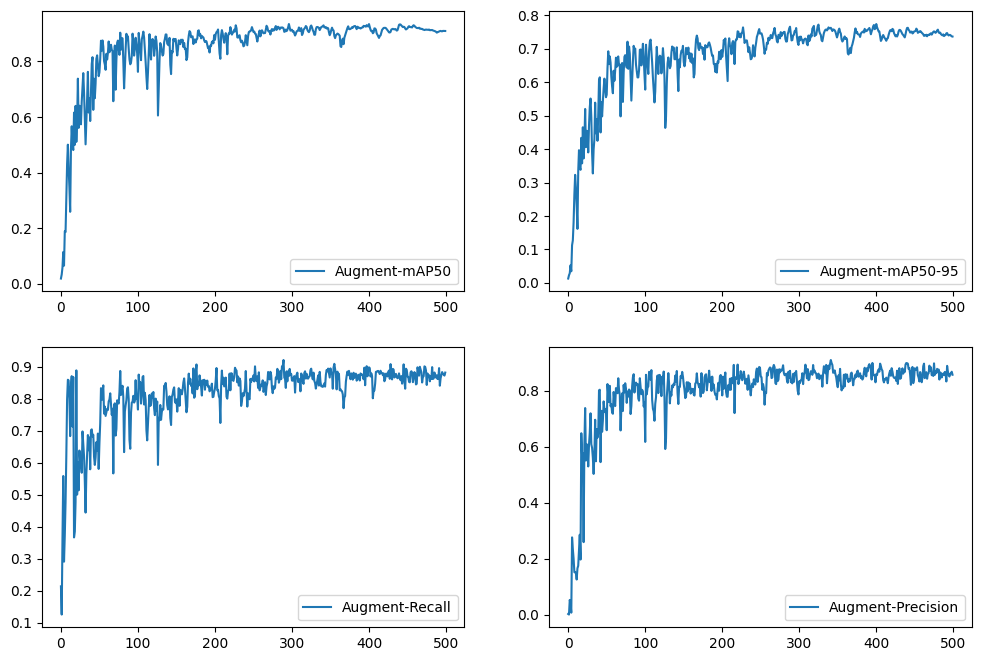

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

augment_slow_adamW_result = 'runs/detect/500_Epoch_AdamW/results.csv'
df2 = pd.read_csv(augment_slow_adamW_result)

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df2['metrics/mAP50(B)'], label='Augment-mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df2['metrics/mAP50-95(B)'], label='Augment-mAP50-95')
plt.legend()

plt.subplot(223)
plt.plot(df2['metrics/recall(B)'], label='Augment-Recall')
plt.legend()

plt.subplot(224)
plt.plot(df2['metrics/precision(B)'], label='Augment-Precision')
plt.legend()

plt.plot()



In [ ]:
df2['metrics/mAP50(B)'][400:499]

,metrics/mAP50(B)
400,0.93414
401,0.92327
402,0.91345
403,0.90851
404,0.91020
...,...
494,0.90844
495,0.90805
496,0.90961
497,0.90953


[]

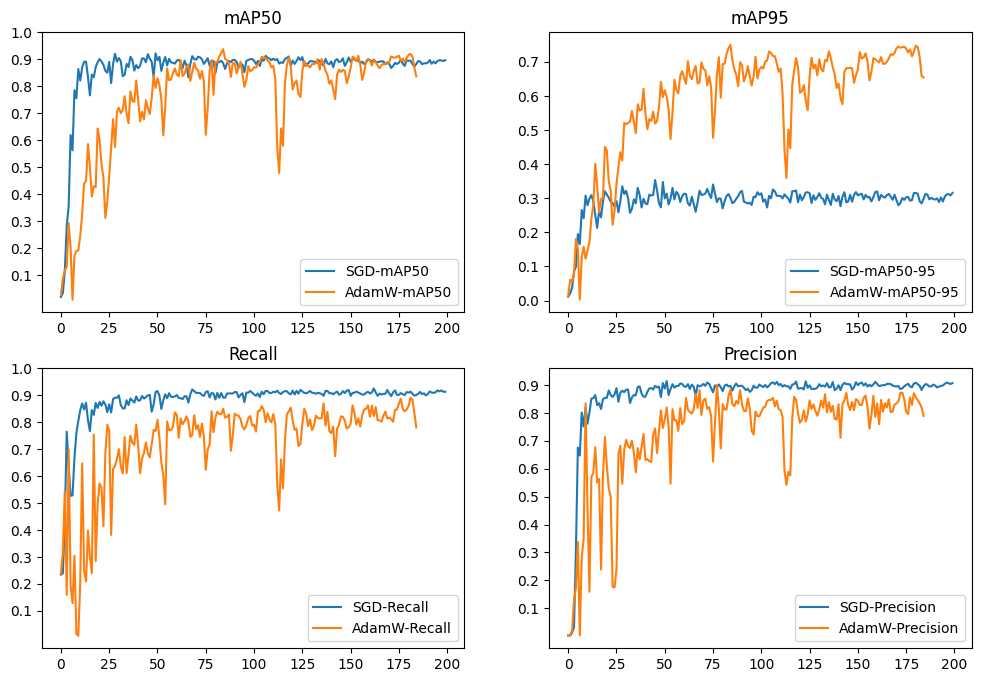

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df1 = pd.read_csv('runs/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('drive/MyDrive/runs/detect/500_Epoch_AdamW/results.csv')

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][0:200], label='AdamW-mAP50')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='SGD-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'][0:200], label='AdamW-mAP50-95')
plt.title('mAP95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='SGD-Recall')
plt.plot(df2['metrics/recall(B)'][0:200], label='AdamW-Recall')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='SGD-Precision')
plt.plot(df2['metrics/precision(B)'][0:200], label='AdamW-Precision')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Precision')
plt.legend()

plt.plot()



[]

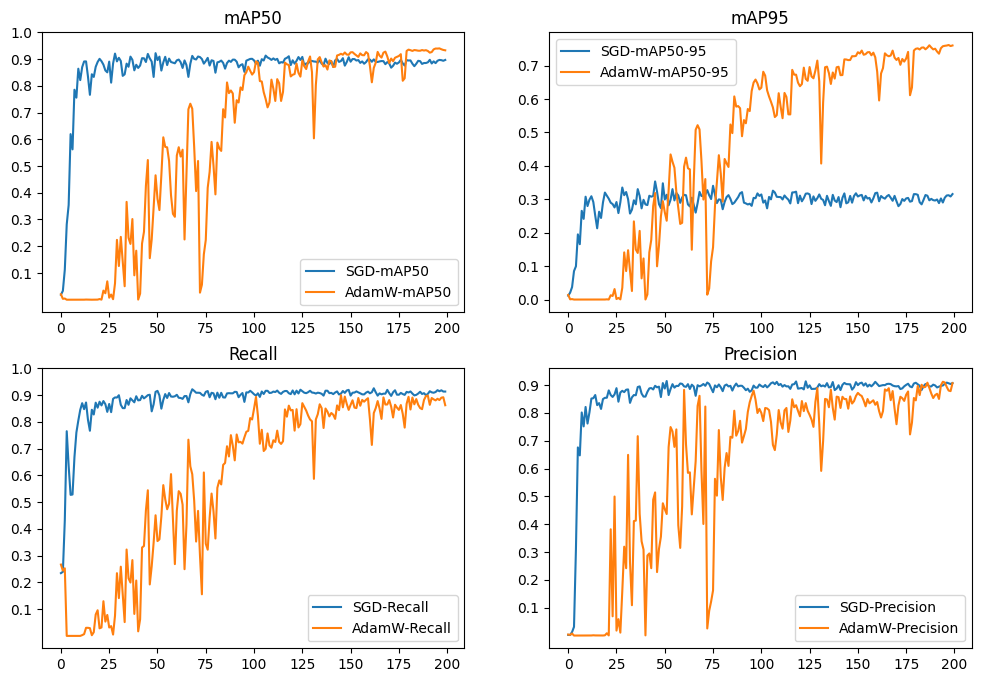

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df1 = pd.read_csv('runs/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('drive/MyDrive/runs2/detect/500_Epoch_AdamW2/results.csv')

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][0:200], label='AdamW-mAP50')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='SGD-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'][0:200], label='AdamW-mAP50-95')
plt.title('mAP95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='SGD-Recall')
plt.plot(df2['metrics/recall(B)'][0:200], label='AdamW-Recall')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='SGD-Precision')
plt.plot(df2['metrics/precision(B)'][0:200], label='AdamW-Precision')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Precision')
plt.legend()

plt.plot()

[]

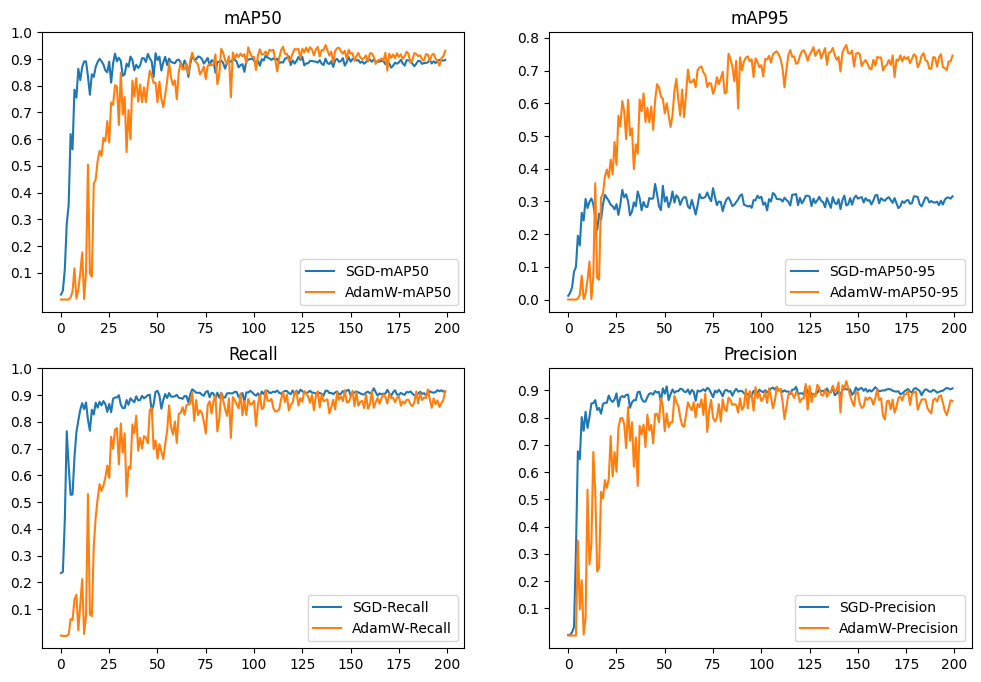

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df1 = pd.read_csv('runs/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('drive/MyDrive/runs3/detect/500_Epoch_AdamW32/results.csv')

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][0:200], label='AdamW-mAP50')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='SGD-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'][0:200], label='AdamW-mAP50-95')
plt.title('mAP95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='SGD-Recall')
plt.plot(df2['metrics/recall(B)'][0:200], label='AdamW-Recall')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='SGD-Precision')
plt.plot(df2['metrics/precision(B)'][0:200], label='AdamW-Precision')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Precision')
plt.legend()

plt.plot()

[]

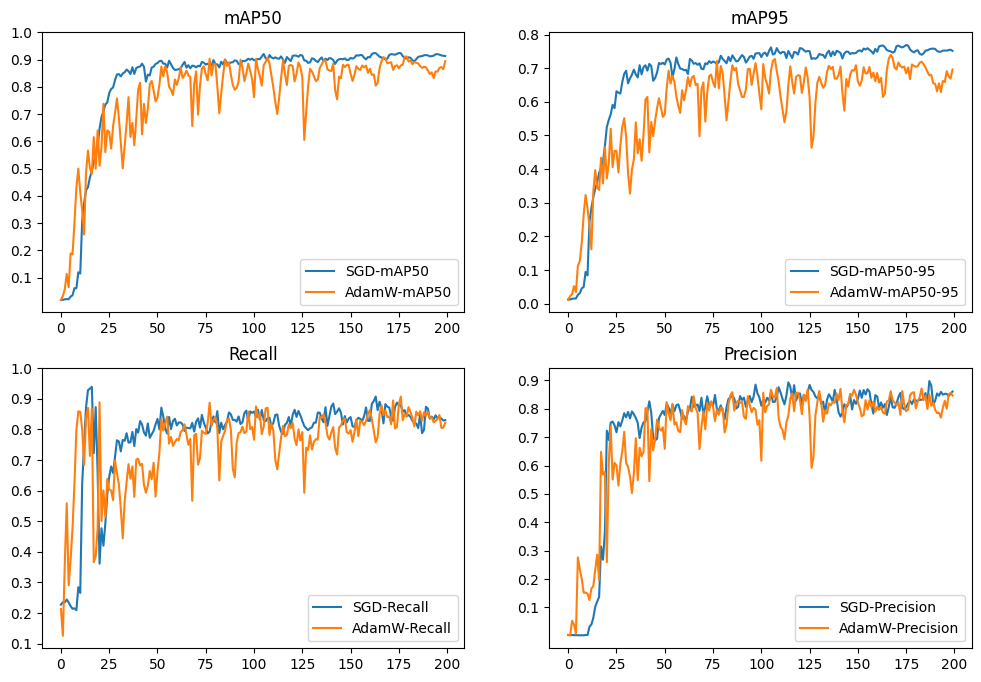

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df1 = pd.read_csv('runs/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('runs/detect/500_Epoch_AdamW/results.csv')

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][0:200], label='AdamW-mAP50')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='SGD-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'][0:200], label='AdamW-mAP50-95')
plt.title('mAP95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='SGD-Recall')
plt.plot(df2['metrics/recall(B)'][0:200], label='AdamW-Recall')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='SGD-Precision')
plt.plot(df2['metrics/precision(B)'][0:200], label='AdamW-Precision')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Precision')
plt.legend()

plt.plot()



[]

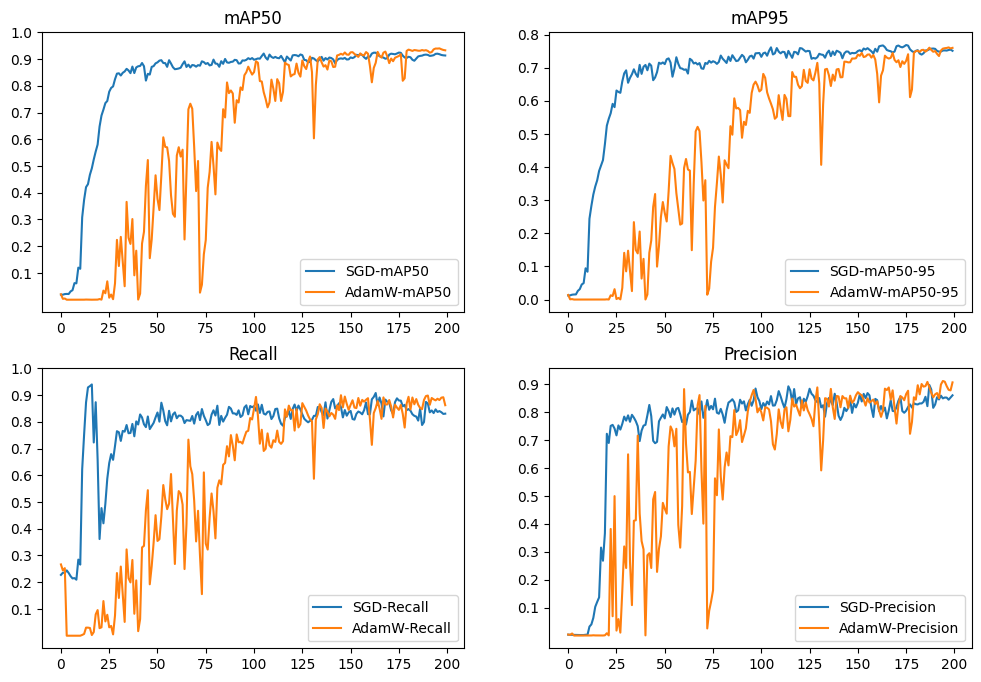

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df1 = pd.read_csv('runs/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('runs/detect/500_Epoch_AdamW2/results.csv')

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][0:200], label='AdamW-mAP50')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='SGD-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'][0:200], label='AdamW-mAP50-95')
plt.title('mAP95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='SGD-Recall')
plt.plot(df2['metrics/recall(B)'][0:200], label='AdamW-Recall')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='SGD-Precision')
plt.plot(df2['metrics/precision(B)'][0:200], label='AdamW-Precision')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Precision')
plt.legend()

plt.plot()



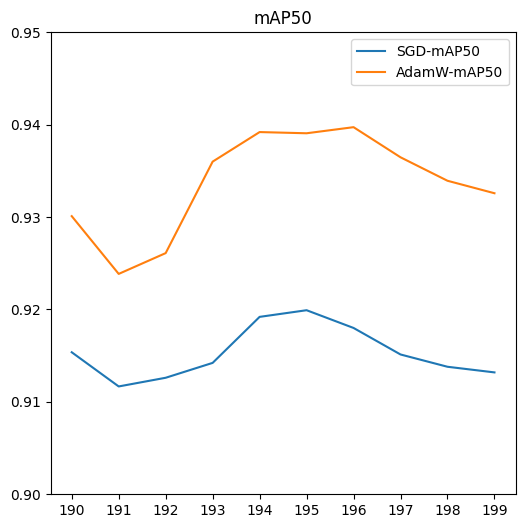

In [ ]:
df1 = pd.read_csv('drive/MyDrive/runs2/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('drive/MyDrive/runs2/detect/500_Epoch_AdamW2/results.csv')

plt.figure(figsize=(6, 6))
plt.plot(df1['metrics/mAP50(B)'][190:200], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][190:200], label='AdamW-mAP50')
# plt.plot(pd.DataFrame([0.98]*200)[190:200], label='Existing-Best-SGD-mAP50')
plt.ylim(0.9, 0.95)
plt.xticks(range(190,200))
plt.title('mAP50')
plt.legend()

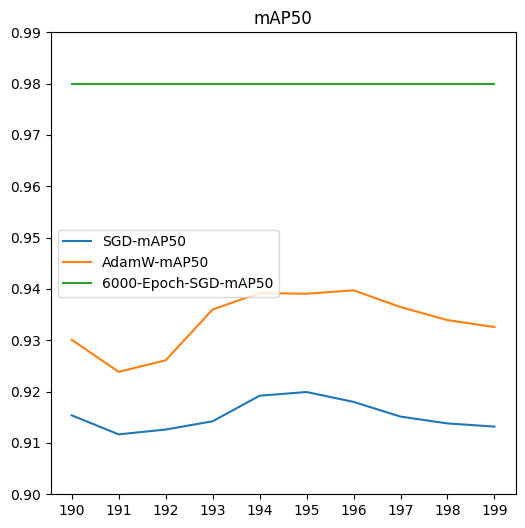

In [ ]:
df1 = pd.read_csv('runs/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('runs/detect/500_Epoch_AdamW2/results.csv')

plt.figure(figsize=(6, 6))
plt.plot(df1['metrics/mAP50(B)'][190:200], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][190:200], label='AdamW-mAP50')
plt.plot(pd.DataFrame([0.98]*200)[190:200], label='6000-Epoch-SGD-mAP50')
plt.ylim(0.9, 0.99)
plt.xticks(range(190,200))
plt.title('mAP50')
plt.legend()

[]

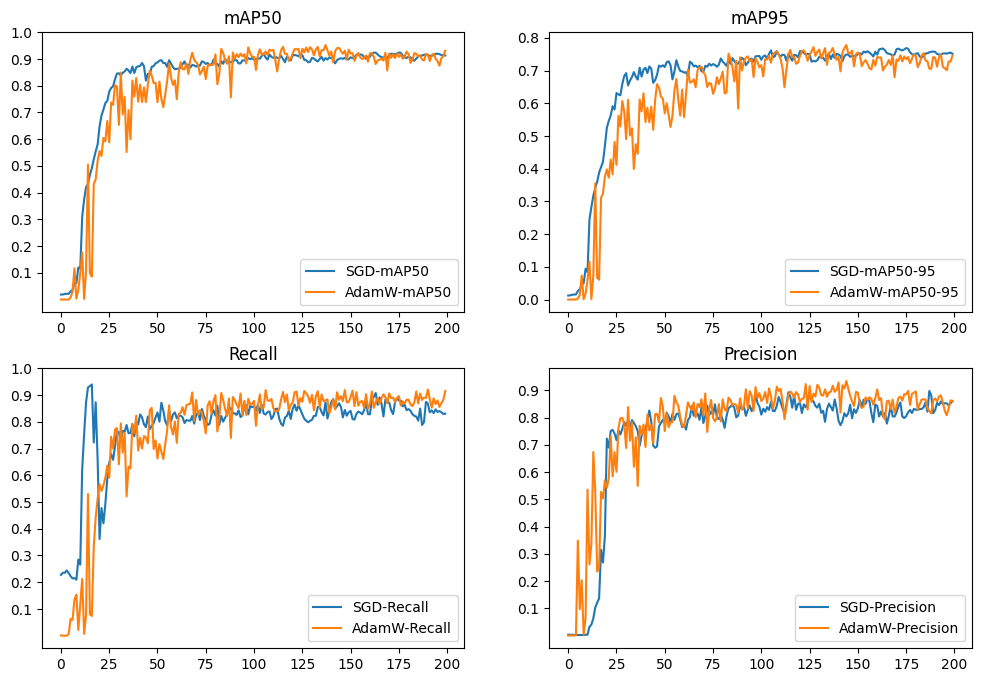

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


df1 = pd.read_csv('runs2/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('runs3/detect/500_Epoch_AdamW32/results.csv')

plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.plot(df1['metrics/mAP50(B)'], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][0:200], label='AdamW-mAP50')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('mAP50')
plt.legend()

plt.subplot(222)
plt.plot(df1['metrics/mAP50-95(B)'], label='SGD-mAP50-95')
plt.plot(df2['metrics/mAP50-95(B)'][0:200], label='AdamW-mAP50-95')
plt.title('mAP95')
plt.legend()

plt.subplot(223)
plt.plot(df1['metrics/recall(B)'], label='SGD-Recall')
plt.plot(df2['metrics/recall(B)'][0:200], label='AdamW-Recall')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Recall')
plt.legend()

plt.subplot(224)
plt.plot(df1['metrics/precision(B)'], label='SGD-Precision')
plt.plot(df2['metrics/precision(B)'][0:200], label='AdamW-Precision')
plt.yticks([.1,.2,.3,.4,.5,.6,.7,.8,.9,1])
plt.title('Precision')
plt.legend()

plt.plot()



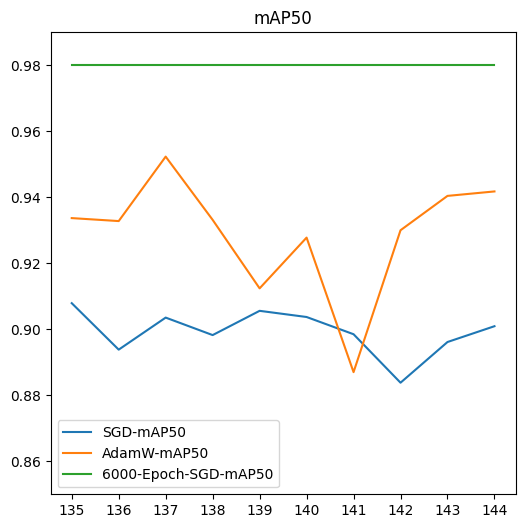

In [ ]:
df1 = pd.read_csv('runs2/detect/200_Epoch_SGD/results.csv')
df2 = pd.read_csv('runs3/detect/500_Epoch_AdamW32/results.csv')

plt.figure(figsize=(6, 6))
plt.plot(df1['metrics/mAP50(B)'][135:145], label='SGD-mAP50')
plt.plot(df2['metrics/mAP50(B)'][135:145], label='AdamW-mAP50')
plt.plot(pd.DataFrame([0.98]*200)[135:145], label='6000-Epoch-SGD-mAP50')
plt.ylim(0.85, 0.99)
plt.xticks(range(135,145))
plt.title('mAP50')
plt.legend()

In [ ]:
import time
time.sleep(600)

KeyboardInterrupt: 